In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust display settings to see all columns
pd.set_option('display.max_columns', None)

# Load the raw dataset based on your folder structure
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\raw\Bengaluru_House_Data.csv') 
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [2]:
# Number of rows and columns
rows, columns = df.shape

print(f"=== Dataset Dimensions ===")
print(f"Number of Rows (Data points): {rows}")
print(f"Number of Features (Columns): {columns}\n")

# Display basic structural info
df.info()

=== Dataset Dimensions ===
Number of Rows (Data points): 13320
Number of Features (Columns): 9

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [3]:
# Identify numerical and categorical columns automatically
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("=== Variable Types ===")
print(f"Numerical Variables ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Variables ({len(categorical_cols)}): {categorical_cols}")

=== Variable Types ===
Numerical Variables (3): ['bath', 'balcony', 'price']
Categorical Variables (6): ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft']


C:\Users\varsh\AppData\Local\Temp\ipykernel_28868\2153259051.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [4]:
# Calculate total missing values and their percentage per column
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

print("=== Missing Data Analysis ===")
print(missing_df[missing_df['Missing Values'] > 0])

=== Missing Data Analysis ===
          Missing Values  Percentage (%)
society             5502       41.306306
balcony              609        4.572072
bath                  73        0.548048
size                  16        0.120120
location               1        0.007508


=== Statistical Summary for Outlier Detection ===
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


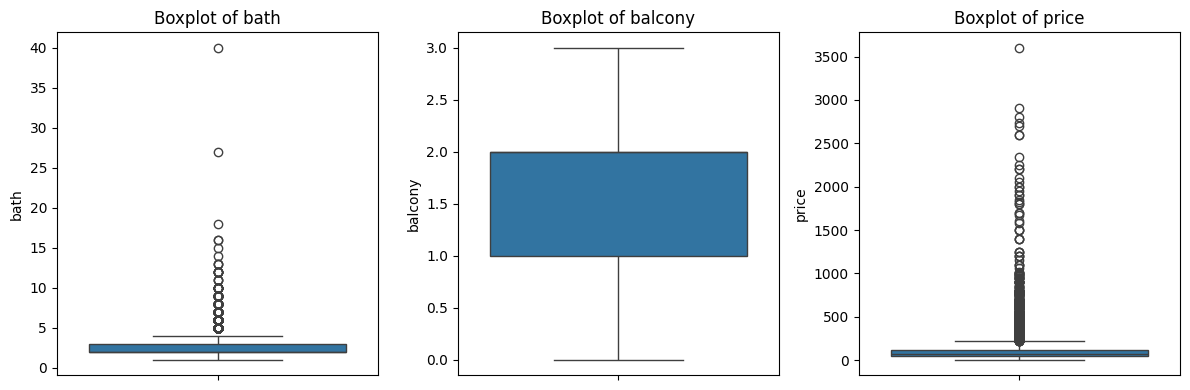

In [5]:
print("=== Statistical Summary for Outlier Detection ===")
print(df[numerical_cols].describe())

# Plot boxplots to visually detect outliers
plt.figure(figsize=(12, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

=== Target Variable (Price) Distribution ===
Skewness of Price: 8.06


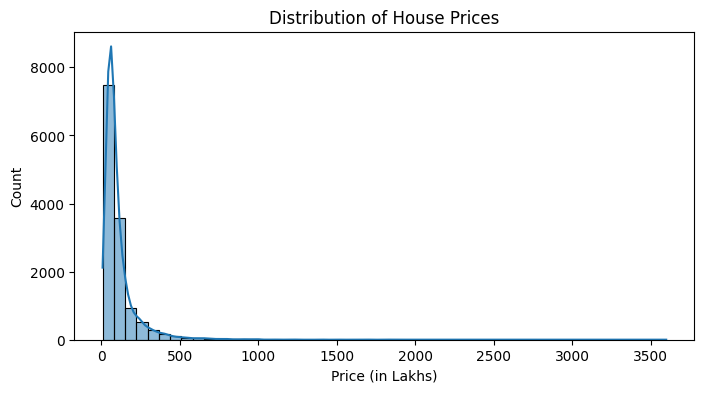


=== Categorical Distribution / Imbalance ===
area_type
Super built-up  Area    65.990991
Built-up  Area          18.153153
Plot  Area              15.202703
Carpet  Area             0.653153
Name: proportion, dtype: float64


In [6]:
print("=== Target Variable (Price) Distribution ===")
print(f"Skewness of Price: {df['price'].skew():.2f}")

# Plot target distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Lakhs)')
plt.show()

print("\n=== Categorical Distribution / Imbalance ===")
# Checking class distribution for 'area_type' as an example
print(df['area_type'].value_counts(normalize=True) * 100)